In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
fl = pd.read_csv('cstJapa.csv')

In [6]:
y = fl['total_flu']
X = fl.drop(columns=['total_flu'])

In [24]:
fl

,Week number,Influenza 2020-2021 (%),Influenza 2019-2020 (%),Temperature,Wind_speed,Surface_Pressure,NO,PM2.5,SO2,CO,Year,total_flu,relative_humidity,NO_SO2
0,23.0,6.260976,5.226923,11.946286,6.024857,100.493714,0.001473,9.729600,0.005577,506.718000,2015.0,1.0,76.634404,0.000008
1,40.0,6.260976,5.226923,11.740286,2.657714,102.480000,0.005648,11.686000,0.008509,427.469429,2015.0,14.0,82.017244,0.000048
2,41.0,6.260976,5.226923,12.106857,3.706857,100.503714,0.005648,11.686000,0.008509,751.117143,2015.0,31.0,90.151233,0.000048
3,42.0,6.260976,5.226923,9.672000,3.170000,101.436286,0.005648,11.686000,0.008509,462.478571,2015.0,18.0,84.163767,0.000048
4,43.0,6.260976,5.226923,10.287143,3.145143,101.372000,0.005648,11.686000,0.008509,577.775857,2015.0,16.0,89.044841,0.000048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,25.0,6.260976,5.226923,13.256786,3.978214,99.964123,0.194743,6.124571,1.996857,173.231429,2024.0,49.0,84.514239,0.388874
368,26.0,6.260976,5.226923,16.717419,3.496461,100.455179,0.233429,4.631429,1.966571,190.740000,2024.0,33.0,84.442906,0.459054
369,27.0,6.260976,5.226923,13.947321,4.243409,100.288555,0.316657,5.722286,1.929714,234.791429,2024.0,34.0,83.120743,0.611058
370,28.0,6.260976,5.226923,14.340097,4.486705,99.996721,0.202571,6.187143,2.112286,203.965714,2024.0,51.0,87.238200,0.427889


# Trying different hyperparameter to get the best result 

In [7]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y = fl['total_flu']
X = fl.drop(columns=['total_flu'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.001, 0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'subsample': [0.6, 0.8, 1.0]
}

# Initialize GradientBoostingRegressor
gbr = GradientBoostingRegressor()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters from grid search
print("Best parameters found: ", grid_search.best_params_)

# Use the best model to predict on the test set
y_pred = grid_search.best_estimator_.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"R-squared: {r2:.3f}")
#print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best parameters found:  {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000, 'subsample': 0.8}
R-squared: 0.445
MAE: 176.70
RMSE: 411.83


In [8]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.7, 0.8, 1.0]
}

# Initialize the Gradient Boosting Regressor with early stopping
gbr = GradientBoostingRegressor(n_iter_no_change=10, validation_fraction=0.2)  # Early stopping

# Use RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=gbr, param_distributions=param_dist, n_iter=20, cv=5, 
                                   scoring='neg_mean_squared_error', verbose=1, n_jobs=-1, random_state=42)

# Fit the model on the training data
random_search.fit(X_train, y_train)

# Get the best parameters
print("Best parameters found: ", random_search.best_params_)

# Use the best model to predict on the test set
y_pred = random_search.best_estimator_.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found:  {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.05}
R-squared: 0.1881
MSE: 248115.2790
MAE: 221.6152
RMSE: 498.1117


In [9]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters:", grid_search.best_params_)

# Best estimator
best_gbr = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_gbr.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE, MAE, and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print(f"Best Gradient Boosting Regressor - R-squared: {r2:.3f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}
Best Gradient Boosting Regressor - R-squared: 0.597
MSE: 123191.59
MAE: 196.96
RMSE: 350.99


In [12]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [250, 300, 350],   # Narrower range around 300
    'learning_rate': [0.15, 0.2, 0.25], # Fine-tuning around 0.2
    'max_depth': [3, 4],                # Small variation on depth
}

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters:", grid_search.best_params_)

# Best estimator
best_gbr = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_gbr.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE, MAE, and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print(f"Best Gradient Boosting Regressor - R-squared: {r2:.3f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Best parameters: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 300}
Best Gradient Boosting Regressor - R-squared: 0.620
MSE: 116230.48
MAE: 165.28
RMSE: 340.93


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Refined parameter grid based on previous best results
param_grid = {
    'n_estimators': [250, 300, 350],   # Narrower range around 300
    'learning_rate': [0.15, 0.2, 0.25], # Fine-tuning around 0.2
    'max_depth': [3, 4],                # Small variation on depth
}

# Initialize Gradient Boosting Regressor with early stopping
gbr = GradientBoostingRegressor(random_state=42, n_iter_no_change=10, validation_fraction=0.2)  # Early stopping

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters:", grid_search.best_params_)

# Best estimator
best_gbr = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_gbr.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE, MAE, and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print(f"Best Gradient Boosting Regressor - R-squared: {r2:.3f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 250}
Best Gradient Boosting Regressor - R-squared: 0.438
MSE: 171840.02
MAE: 225.91
RMSE: 414.54


# Best gradient boosting result without the huber loss 

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [250, 300, 350],   
    'learning_rate': [0.15, 0.2, 0.25], 
    'max_depth': [3, 4],                
    'min_samples_split': [2, 5],        
    'min_samples_leaf': [1, 2],        
    'subsample': [0.8, 1.0]            
}

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Use RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=gbr, param_distributions=param_dist, n_iter=50, cv=5, 
                                   scoring='neg_mean_squared_error', verbose=1, n_jobs=-1, random_state=42)

# Fit the model on the training data
random_search.fit(X_train, y_train)

# Get the best parameters
print("Best parameters found: ", random_search.best_params_)

# Use the best model to predict on the test set
y_pred = random_search.best_estimator_.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"R-squared: {r2:.3f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:  {'subsample': 1.0, 'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.2}
R-squared: 0.620
MSE: 116242.33
MAE: 165.28
RMSE: 340.94


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [250, 300, 350],   
    'learning_rate': [0.15, 0.2, 0.25], # Fine-tuning around 0.2
    'max_depth': [3, 4],                # Small variation on depth
    'min_samples_split': [2, 5],        # Reduced split size
    'min_samples_leaf': [1, 2],         # Min leaf size
    'subsample': [0.8, 1.0]             # Subsample for reducing overfitting
}

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(loss='huber',random_state=42)

# Use RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=gbr, param_distributions=param_dist, n_iter=20, cv=5, 
                                   scoring='neg_mean_squared_error', verbose=1, n_jobs=-1, random_state=42)

# Fit the model on the training data
random_search.fit(X_train, y_train)

# Get the best parameters
print("Best parameters found: ", random_search.best_params_)

# Use the best model to predict on the test set
y_pred = random_search.best_estimator_.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"R-squared: {r2:.3f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found:  {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.15}
R-squared: 0.766
MSE: 71652.90
MAE: 144.87
RMSE: 267.68


# Gradient boosting with random search for AQV + WV - best result 

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [250, 300, 350],   #  range of trees
    'learning_rate': [0.15, 0.2, 0.25], # Fine-tuning around 0.2
    'max_depth': [3, 4],                # Small variation on depth
    'min_samples_split': [2, 5],        # Reduced split size
    'min_samples_leaf': [1, 2],         # Min leaf size
    'subsample': [0.8, 1.0]             # Subsample for reducing overfitting
}

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(loss='huber',random_state=42)

# Use RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=gbr, param_distributions=param_dist, n_iter=50, cv=5, 
                                   scoring='neg_mean_squared_error', verbose=1, n_jobs=-1, random_state=42)

# Fit the model on the training data
random_search.fit(X_train, y_train)

# Get the best parameters
print("Best parameters found: ", random_search.best_params_)

# Use the best model to predict on the test set
y_pred = random_search.best_estimator_.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"R-squared: {r2:.3f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:  {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.2}
R-squared: 0.774
MSE: 69129.97
MAE: 143.76
RMSE: 262.93


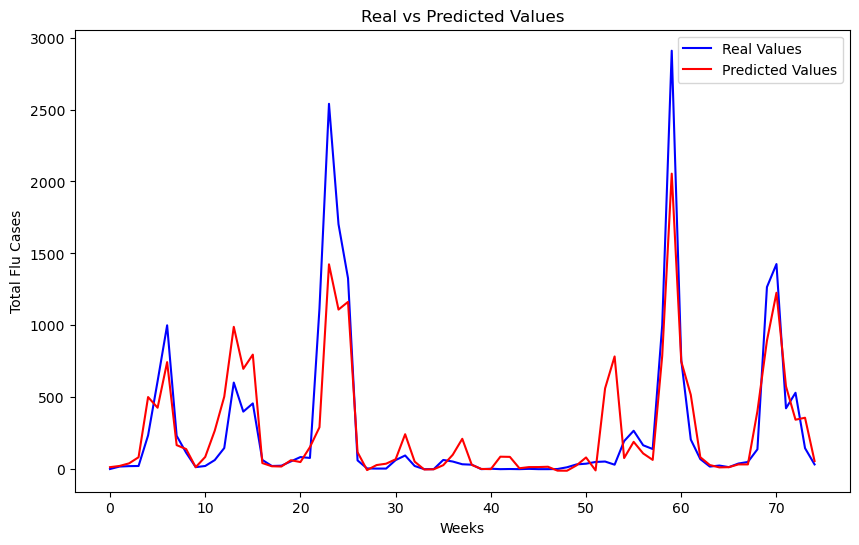

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by indices (if necessary, especially if your data is time-ordered)
sorted_indices = np.argsort(y_test.index)

# Ensure both y_test and y_pred are sorted and aligned
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test.iloc[sorted_indices], label="Real Values", color='blue')
plt.plot(np.arange(len(y_pred)), y_pred[sorted_indices], label="Predicted Values", color='red')
plt.title("Real vs Predicted Values")
plt.xlabel("Weeks")
plt.ylabel("Total Flu Cases")
plt.legend()
plt.show()


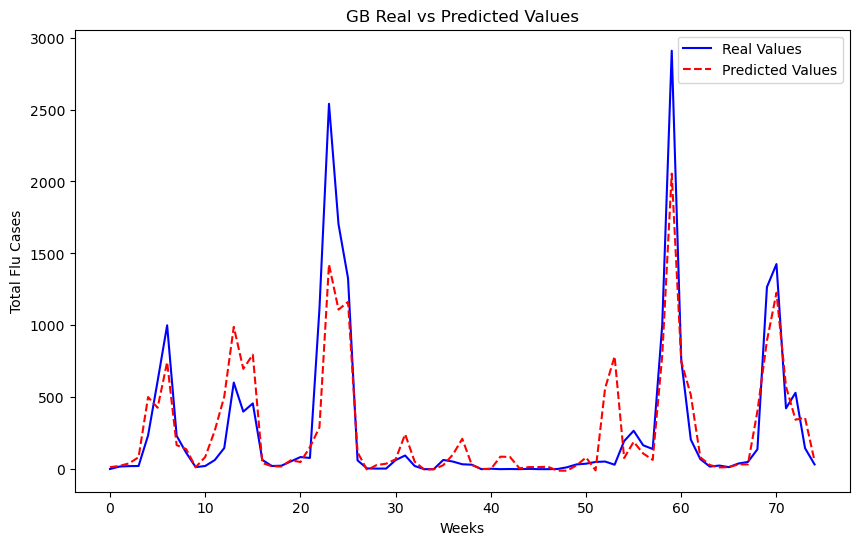

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by indices (if necessary, especially if your data is time-ordered)
sorted_indices = np.argsort(y_test.index)

# Ensure both y_test and y_pred are sorted and aligned
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test.iloc[sorted_indices], label="Real Values", color='blue')
plt.plot(np.arange(len(y_pred)), y_pred[sorted_indices], label="Predicted Values", color='red', linestyle='--')  # Red dotted line for predictions
plt.title("GB Real vs Predicted Values")
plt.xlabel("Weeks")
plt.ylabel("Total Flu Cases")
plt.legend()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_3564\1709232239.py:6: RuntimeWarning: invalid value encountered in log1p
  y_pred_log = np.log1p(y_pred)


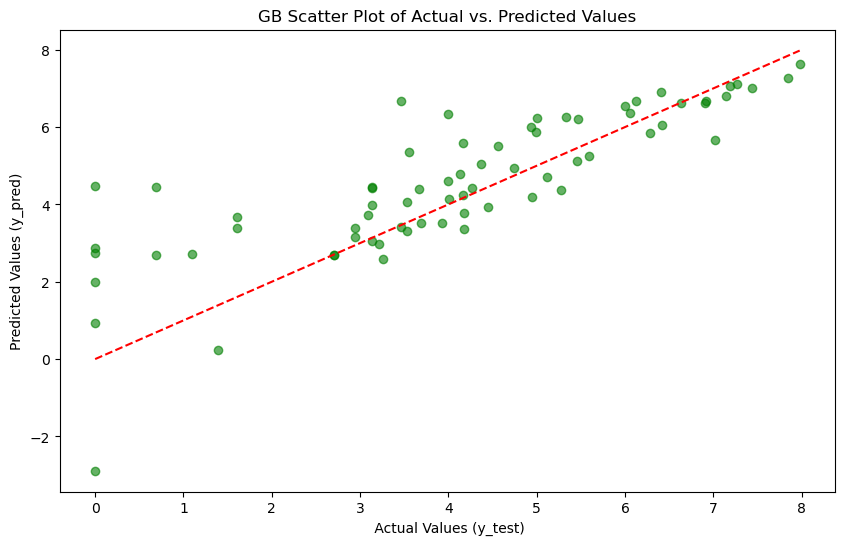

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Apply log transformation to both y_test and y_pred
y_test_log = np.log1p(y_test)  # log1p(x) is log(x + 1) to handle zeros
y_pred_log = np.log1p(y_pred)

# Create scatter plot for log-transformed values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_log, y_pred_log, color='green', alpha=0.6)  # Green dots for scatter
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], color='red', linestyle='--')  # 45-degree line

# Add labels and title
plt.title("GB Scatter Plot of Actual vs. Predicted Values")
plt.xlabel(" Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")

# Show plot
plt.show()
